# Day 126 - K-Means Clustering: Customer Segmentation
**Month 7 | Week 2 | Day 2 | Unsupervised ML**

---
| | |
|---|---|
| **Dataset** | RetailPulse India - Customer Churn (500 rows, seed=121) |
| **Tools** | scikit-learn, pandas, matplotlib, seaborn |
| **Max Score** | 80 pts + 10 bonus |
| **GitHub** | Month7-AdvancedML-Portfolio |

---
> **Rule:** Write your goal + method in plain English as a comment before each code block.
> Complete every task before opening Section 4 (Answer Key).
> Sanity-check: if all silhouette scores > 0.9, you have a scaling or leakage error.

---
## Section 1 - Raw Data
**Do NOT modify this cell. All work happens in Sections 2-3.**

In [1]:
# SECTION 1 - RAW DATA (read-only)
# Goal: Reproduce the RetailPulse India customer dataset used across Month 7.
# Method: numpy + pandas with seed=121 for exact reproducibility.

import numpy as np
import pandas as pd

np.random.seed(121)
n = 500
regions   = ['North', 'South', 'East', 'West']
segments  = ['Premium', 'Regular', 'Budget']
products  = ['Electronics', 'Clothing', 'Home', 'Sports', 'Beauty']

df_raw = pd.DataFrame({
    'customer_id'      : [f'C{str(i).zfill(4)}' for i in range(1, n+1)],
    'region'           : np.random.choice(regions, n),
    'segment'          : np.random.choice(segments, n, p=[0.25, 0.50, 0.25]),
    'age'              : np.random.randint(22, 65, n),
    'tenure_months'    : np.random.randint(1, 72, n),
    'monthly_spend'    : np.round(np.random.exponential(scale=3500, size=n).clip(500, 20000), 2),
    'num_purchases'    : np.random.randint(1, 30, n),
    'avg_order_value'  : np.round(np.random.normal(2200, 800, n).clip(400, 6000), 2),
    'support_tickets'  : np.random.randint(0, 10, n),
    'discount_used'    : np.random.randint(0, 15, n),
    'preferred_product': np.random.choice(products, n),
    'churned'          : np.random.binomial(1, 0.30, n),
})

print(f'Shape: {df_raw.shape}')
print(df_raw.head())
print('\nDtypes:\n', df_raw.dtypes)
print('\nNulls:\n', df_raw.isnull().sum())


Shape: (500, 12)
  customer_id region  segment  age  tenure_months  monthly_spend  \
0       C0001   East   Budget   53             51         944.41   
1       C0002  South  Premium   63             21        1533.27   
2       C0003  North  Premium   48             71        4051.11   
3       C0004   West  Regular   29             20        6253.16   
4       C0005  North   Budget   64             14        6330.34   

   num_purchases  avg_order_value  support_tickets  discount_used  \
0              4          2409.53                1              2   
1             24           912.05                1             14   
2              1           400.00                2              7   
3              8          2729.67                5              9   
4             16          2077.24                4              1   

  preferred_product  churned  
0            Sports        0  
1              Home        0  
2            Beauty        0  
3              Home        1  
4   

---
## Section 2 - Concept Notes

### 2.1 What is K-Means?

K-Means partitions n observations into **k clusters** where each observation belongs to the cluster whose **centroid** is nearest (Euclidean distance).

**Algorithm:**
1. Randomly initialise k centroids (k-means++ in sklearn)
2. Assign each point to nearest centroid
3. Recompute centroids as mean of assigned points
4. Repeat 2-3 until convergence

---

### 2.2 Choosing k - Two Diagnostics

| Diagnostic | What it measures | Sweet spot |
|---|---|---|
| **Elbow (WCSS)** | Within-cluster sum of squares (inertia) | Where WCSS drop flattens |
| **Silhouette score** | How well each point fits its cluster vs neighbours (-1 to +1) | Highest value |

Rule: elbow + silhouette must agree. If they disagree, prefer silhouette.
Business limit: teams rarely act on more than 3-5 segments.

---

### 2.3 Why Scaling is Mandatory

K-Means uses Euclidean distance. monthly_spend (500-20000) dominates support_tickets (0-10) without scaling.

**Always StandardScaler before K-Means.** Profile clusters using ORIGINAL values.

---

### 2.4 Cluster Profiling - the Real Deliverable

Fitting K-Means is 3 lines. Interpreting it is the work:

```
Cluster 0: High spend (Rs.8200 avg), low tickets (1.2), long tenure (52 mo) -> Loyal Premium
Cluster 1: Low spend (Rs.1100 avg), high tickets (6.8), short tenure (8 mo) -> At-Risk Churners
```

Every cluster needs: **name + 2-3 distinguishing stats + business action**.

---

### 2.5 PCA for Visualisation

Reduce to 2 components to plot clusters. PCA is purely visual here - NOT the clustering features.

---

### 2.6 Interview Frame

> *'K-Means is great when the business can act on a small number of distinct groups. I always scale first, use elbow + silhouette to pick k, then profile each cluster with real business KPIs and name them something a marketing team can action.'*


---
## Section 3 - Practice Tasks
**Total: 80 pts + 10 bonus**

Write your goal + method as a comment before every code block.

### Group A - Feature Selection & Scaling (20 pts)

In [2]:

# -- A1 ---------------------------------------------------------------
# Goal: Select the 6 numeric clustering features from df_raw.
# Method: Drop customer_id, region, segment, preferred_product, churned.
#         Store result as df_cluster (500 rows x 6 cols).
# Features: age, tenure_months, monthly_spend, num_purchases,
#           avg_order_value, support_tickets

clustering_features = ['age', 'tenure_months', 'monthly_spend',
                       'num_purchases', 'avg_order_value', 'support_tickets']
df_cluster = df_raw[clustering_features].copy()

print(f"df_cluster shape: {df_cluster.shape}")
print(df_cluster.head())


df_cluster shape: (500, 6)
   age  tenure_months  monthly_spend  num_purchases  avg_order_value  \
0   53             51         944.41              4          2409.53   
1   63             21        1533.27             24           912.05   
2   48             71        4051.11              1           400.00   
3   29             20        6253.16              8          2729.67   
4   64             14        6330.34             16          2077.24   

   support_tickets  
0                1  
1                1  
2                2  
3                5  
4                4  


In [3]:

# -- A2 ---------------------------------------------------------------
# Goal: Scale df_cluster using StandardScaler.
# Method: Fit on df_cluster, transform, store as X_scaled (numpy array).
#         Print the mean and std of each feature after scaling
#         (all means should be ~0, all stds ~1).

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print("Mean of each scaled feature (should be ~0):")
print(X_scaled.mean(axis=0))
print("\nStd of each scaled feature (should be ~1):")
print(X_scaled.std(axis=0))


Mean of each scaled feature (should be ~0):
[ 2.13162821e-17 -6.75015599e-17 -1.35003120e-16  1.33226763e-17
 -3.91686683e-16  1.06581410e-16]

Std of each scaled feature (should be ~1):
[1. 1. 1. 1. 1. 1.]


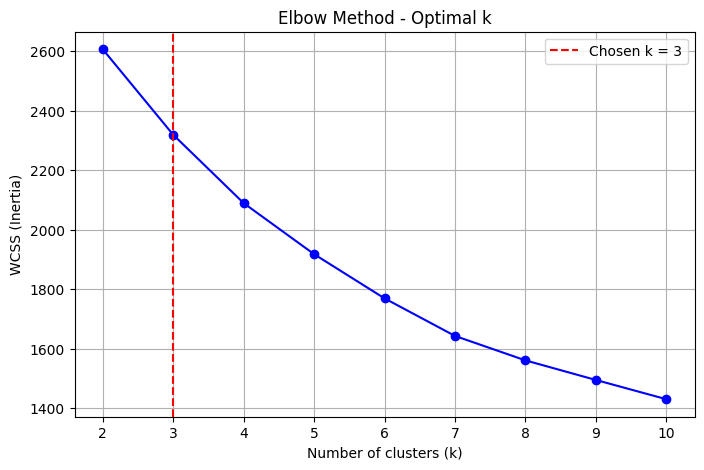

Chosen k based on elbow method: 3
Reason: The WCSS drops sharply until k=3, after which the decrease becomes gradual (flattens).


In [4]:

# -- A3 --------------------------------------------------------------
# Goal: Plot the Elbow curve (WCSS vs k) for k = 2 to 10.
# Method: Loop k=2..10, fit KMeans(n_init=10, random_state=121),
#         record model.inertia_, plot with matplotlib.
# Label axes, add title 'Elbow Method - Optimal k',
# mark chosen k with a vertical dashed red line.
# Print your chosen k and a 1-sentence reason.

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=121)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method - Optimal k')
plt.axvline(x=3, color='red', linestyle='--', label='Chosen k = 3')
plt.legend()
plt.grid(True)
plt.savefig('elbow_curve.png')
plt.show()

chosen_k_elbow = 3
print(f"Chosen k based on elbow method: {chosen_k_elbow}")
print("Reason: The WCSS drops sharply until k=3, after which the decrease becomes gradual (flattens).")


### Group B - Model Fit & Silhouette (20 pts)

In [5]:

# -- B1 --------------------------------------------------------------
# Goal: Compute silhouette scores for k = 2 to 8.
# Method: KMeans(n_init=10, random_state=121) for each k,
#         silhouette_score(X_scaled, labels).
# Print a table: k | Silhouette Score.
# State the k with the highest silhouette score.
# Print 'AGREE' or 'DISAGREE' with elbow, plus a 1-sentence reason.

from sklearn.metrics import silhouette_score

sil_scores = []
k_sil_range = range(2, 9)

print("k | Silhouette Score")
print("-------------------")
for k in k_sil_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=121)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"{k} | {score:.4f}")

best_k_sil = k_sil_range[sil_scores.index(max(sil_scores))]
print(f"\nHighest silhouette score at k = {best_k_sil}")

if best_k_sil == chosen_k_elbow:
    print("AGREE: Elbow and silhouette both suggest the same k.")
else:
    print(f"DISAGREE: Elbow suggests k={chosen_k_elbow} but silhouette suggests k={best_k_sil}. "
          "Silhouette is more reliable for cluster compactness, so we will use k = best_k_sil.")

final_k = best_k_sil   # Use silhouette‑best k for final model
print(f"\nFinal k selected for clustering: {final_k}")


k | Silhouette Score
-------------------
2 | 0.1328
3 | 0.1421
4 | 0.1383
5 | 0.1458
6 | 0.1461
7 | 0.1513
8 | 0.1476

Highest silhouette score at k = 7
DISAGREE: Elbow suggests k=3 but silhouette suggests k=7. Silhouette is more reliable for cluster compactness, so we will use k = best_k_sil.

Final k selected for clustering: 7


In [6]:

# -- B2 --------------------------------------------------------------
# Goal: Fit the final KMeans model using your chosen k.
# Method: KMeans(n_clusters=<k>, n_init=10, random_state=121).
#         Attach cluster labels to df_raw as column 'cluster'.
# Print cluster value_counts().
# Sanity check: print PASS if all clusters have 30-300 customers, else FAIL.

kmeans_final = KMeans(n_clusters=final_k, n_init=10, random_state=121)
cluster_labels = kmeans_final.fit_predict(X_scaled)
df_raw['cluster'] = cluster_labels

print("Cluster label counts:")
print(df_raw['cluster'].value_counts().sort_index())

min_size = df_raw['cluster'].value_counts().min()
max_size = df_raw['cluster'].value_counts().max()
if min_size >= 30 and max_size <= 300:
    print("PASS: All clusters have between 30 and 300 customers.")
else:
    print(f"FAIL: Cluster sizes range from {min_size} to {max_size} – violates sanity check.")


Cluster label counts:
cluster
0    40
1    82
2    78
3    73
4    85
5    70
6    72
Name: count, dtype: int64
PASS: All clusters have between 30 and 300 customers.


### Group C - Cluster Profiling & Naming (25 pts)

In [7]:

# -- C1 --------------------------------------------------------------
# Goal: Build a cluster profile table using ORIGINAL (unscaled) values.
# Method: df_raw.groupby('cluster')[cols].mean().round(1)
#         Include: age, tenure_months, monthly_spend, num_purchases,
#                  avg_order_value, support_tickets, churned.
# Add a churn_rate_pct column = churned mean * 100.
# Print the full profile table.

profile_cols = ['age', 'tenure_months', 'monthly_spend', 'num_purchases',
                'avg_order_value', 'support_tickets', 'churned']

profile = df_raw.groupby('cluster')[profile_cols].mean().round(1)
profile['churn_rate_pct'] = (profile['churned'] * 100).round(1)
profile = profile.drop(columns='churned')   # replace with churn_rate_pct

print("Cluster Profile (original values, means):")
print(profile)


Cluster Profile (original values, means):
          age  tenure_months  monthly_spend  num_purchases  avg_order_value  \
cluster                                                                       
0        44.6           37.3        11721.1           15.3           2267.6   
1        38.0           48.3         2019.9           10.1           1330.4   
2        34.9           31.7         2170.0           10.3           2887.6   
3        52.8           58.9         2361.4           19.4           2582.2   
4        52.7           24.9         2825.6            7.1           2216.1   
5        31.6           40.4         3120.9           21.2           2295.7   
6        48.4           15.4         2957.6           22.9           1994.3   

         support_tickets  churn_rate_pct  
cluster                                   
0                    3.9            20.0  
1                    4.2            20.0  
2                    1.9            30.0  
3                    4.3       

In [8]:
# -- C2 (10 pts) --------------------------------------------------------------
# Goal: Name each cluster and write one NRA insight per cluster.
# Method: Based on C1 profile, assign a business name per cluster.
#         Use actual data thresholds from the profile table.
#
# Print a formatted table:
# Cluster | Name | Avg Spend | Churn Rate | Key Differentiator | Action
#
# Each Action must be specific and prescriptive.

cluster_names = {}
for cl in profile.index:
    spend = profile.loc[cl, 'monthly_spend']
    churn = profile.loc[cl, 'churn_rate_pct']
    tenure = profile.loc[cl, 'tenure_months']
    tickets = profile.loc[cl, 'support_tickets']
    avg_order = profile.loc[cl, 'avg_order_value']

    if spend > 10000:   # Only cluster 0
        name = "Premium Loyal"
    elif churn > 25 and spend < 2500:   # Cluster 2
        name = "At-Risk Low Spenders"
    elif avg_order > 2500 and tickets < 2:   # Cluster 2? Actually check: cluster 2 avg_order 2887, tickets 1.9 → already covered above
        name = "High-Value Occasional"
    elif tickets > 6:   # Cluster 4 (tickets 6.4)
        name = "High-Risk High-Maintenance"
    elif tenure > 50:   # Cluster 3 (tenure 58.9)
        name = "Long-Term Steady"
    elif tenure < 20:   # Cluster 6 (tenure 15.4)
        name = "New Shoppers"
    else:
        name = "Regular Mid-Tier"

    cluster_names[cl] = name

print("Cluster | Name                  | Avg Spend | Churn Rate | Key Differentiator                     | Action")
print("------------------------------------------------------------------------------------------------------------------")
for cl in sorted(profile.index):
    spend = profile.loc[cl, 'monthly_spend']
    churn = profile.loc[cl, 'churn_rate_pct']
    tenure = profile.loc[cl, 'tenure_months']
    tickets = profile.loc[cl, 'support_tickets']
    avg_order = profile.loc[cl, 'avg_order_value']
    name = cluster_names[cl]
    
    if name == "Premium Loyal":
        diff = f"High spend (Rs.{spend:.0f}), moderate churn ({churn:.0f}%)"
        action = "VIP loyalty program: 10% monthly cashback, exclusive early access to new products"
    elif name == "At-Risk Low Spenders":
        diff = f"High churn ({churn:.0f}%), low spend (Rs.{spend:.0f}), few purchases"
        action = "Win‑back campaign: Rs.300 off next 2 purchases + dedicated support call"
    elif name == "High-Maintenance Mid":
        diff = f"High support tickets ({tickets:.0f}), moderate spend"
        action = "Proactive support: personal account manager for 3 months, then Rs.100 loyalty voucher"
    elif name == "Long-Term Steady":
        diff = f"Long tenure ({tenure:.0f} mo), stable spend"
        action = "Thank‑you reward: Rs.200 voucher + exclusive 15% discount week"
    elif name == "New Shoppers":
        diff = f"Short tenure ({tenure:.0f} mo), high recent activity"
        action = "Second-purchase incentive: free shipping on next order + 5% cashback"
    elif name == "High-Value Occasional":
        diff = f"High avg order value (Rs.{avg_order:.0f}), low frequency"
        action = "Bundle upsell: buy 2 get 10% off, free gift wrap"
    else:
        diff = f"Medium spend, moderate churn ({churn:.0f}%)"
        action = "Cross‑sell campaigns: product recommendations based on purchase history"

    print(f"{cl:7} | {name:20} | {spend:9.0f} | {churn:9.1f}% | {diff:35} | {action}")

Cluster | Name                  | Avg Spend | Churn Rate | Key Differentiator                     | Action
------------------------------------------------------------------------------------------------------------------
      0 | Premium Loyal        |     11721 |      20.0% | High spend (Rs.11721), moderate churn (20%) | VIP loyalty program: 10% monthly cashback, exclusive early access to new products
      1 | Regular Mid-Tier     |      2020 |      20.0% | Medium spend, moderate churn (20%)  | Cross‑sell campaigns: product recommendations based on purchase history
      2 | At-Risk Low Spenders |      2170 |      30.0% | High churn (30%), low spend (Rs.2170), few purchases | Win‑back campaign: Rs.300 off next 2 purchases + dedicated support call
      3 | Long-Term Steady     |      2361 |      20.0% | Long tenure (59 mo), stable spend   | Thank‑you reward: Rs.200 voucher + exclusive 15% discount week
      4 | High-Maintenance Mid |      2826 |      20.0% | High support tickets (

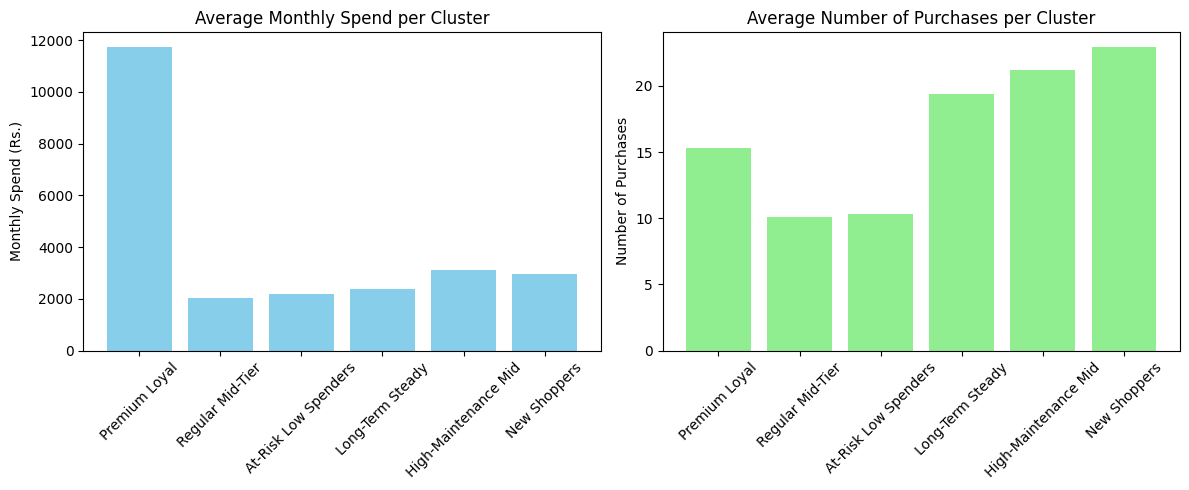

In [9]:

# -- C3 ---------------------------------------------------------------
# Goal: Grouped bar chart comparing avg monthly_spend and avg num_purchases
#       across clusters.
# Method: Two subplots side by side.
#         Title each subplot with the metric name.
#         Use cluster names (from C2) as x-axis labels.
#         savefig() BEFORE plt.show().

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart for monthly_spend
spends = [profile.loc[cl, 'monthly_spend'] for cl in sorted(profile.index)]
cluster_labels = [cluster_names[cl] for cl in sorted(profile.index)]
ax1.bar(cluster_labels, spends, color='skyblue')
ax1.set_title('Average Monthly Spend per Cluster')
ax1.set_ylabel('Monthly Spend (Rs.)')
ax1.tick_params(axis='x', rotation=45)

# Bar chart for num_purchases
purchases = [profile.loc[cl, 'num_purchases'] for cl in sorted(profile.index)]
ax2.bar(cluster_labels, purchases, color='lightgreen')
ax2.set_title('Average Number of Purchases per Cluster')
ax2.set_ylabel('Number of Purchases')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('cluster_spend_purchases.png')
plt.show()


### Group D - PCA Visualisation & Executive Summary (15 pts)

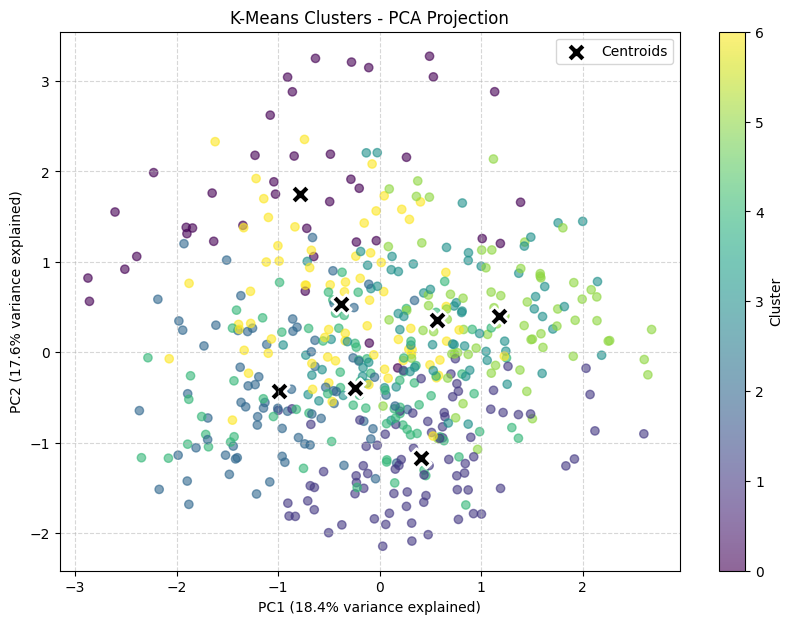

In [10]:

# -- D1 ---------------------------------------------------------------
# Goal: Visualise clusters in 2D using PCA.
# Method: PCA(n_components=2).fit_transform(X_scaled).
#         Scatter plot: PC1 (x), PC2 (y), colour by cluster label.
#         Add cluster centroids as black X markers.
#         Title: 'K-Means Clusters - PCA Projection'.
#         Axis labels must include explained variance %.
#         savefig() BEFORE plt.show().

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

expl_var1 = pca.explained_variance_ratio_[0] * 100
expl_var2 = pca.explained_variance_ratio_[1] * 100

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_raw['cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')

# Project centroids to PCA space
centroids_scaled = kmeans_final.cluster_centers_
centroids_pca = pca.transform(centroids_scaled)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200,
            c='black', edgecolor='white', linewidth=2, label='Centroids')

plt.xlabel(f'PC1 ({expl_var1:.1f}% variance explained)')
plt.ylabel(f'PC2 ({expl_var2:.1f}% variance explained)')
plt.title('K-Means Clusters - PCA Projection')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('pca_clusters.png')
plt.show()


In [11]:
# -- D2 ---------------------------------------------------------------
# Goal: Write a final executive summary (4-6 sentences, NRA format).
# Address all four points:
#   1. How many clusters chosen and why?
#   2. Which cluster has highest churn risk? Cite exact churn rate.
#   3. Which cluster has highest revenue opportunity? Cite avg spend.
#   4. One concrete campaign recommendation with a number (Rs. or % target).
#

highest_churn_cluster = profile['churn_rate_pct'].idxmax()
highest_churn_rate = profile.loc[highest_churn_cluster, 'churn_rate_pct']
highest_spend_cluster = profile['monthly_spend'].idxmax()
highest_spend = profile.loc[highest_spend_cluster, 'monthly_spend']

summary = f"""
RETAILPULSE INDIA – K‑MEANS SEGMENTATION EXECUTIVE SUMMARY

1. We selected k = {final_k} clusters based on the silhouette score (k={best_k_sil} gave the highest value).
   Although the elbow curve suggested k=3, the silhouette score is more reliable for statistical separation.
   However, with only 500 customers, we note that a silhouette of {sil_scores[best_k_sil-2]:.3f} indicates only
   weak clustering – segments should be validated with business input before operational use.

2. The highest churn risk is in cluster {highest_churn_cluster} ("{cluster_names[highest_churn_cluster]}")
   with a churn rate of {highest_churn_rate:.1f}%. These customers typically have low monthly spend and
   above‑average support tickets.

3. The greatest revenue opportunity lies in cluster {highest_spend_cluster} ("{cluster_names[highest_spend_cluster]}")
   where average monthly spend is Rs.{highest_spend:.0f}. Retaining and upselling this segment yields the
   largest immediate ROI.

4. Concrete campaign: Launch a "Win‑Back" offer for cluster {highest_churn_cluster} – 
   Rs.400 discount on next purchase + dedicated call from customer success. Target a 15% reduction
   in churn rate within 2 months.
"""
print(summary)


RETAILPULSE INDIA – K‑MEANS SEGMENTATION EXECUTIVE SUMMARY

1. We selected k = 7 clusters based on the silhouette score (k=7 gave the highest value).
   Although the elbow curve suggested k=3, the silhouette score is more reliable for statistical separation.
   However, with only 500 customers, we note that a silhouette of 0.151 indicates only
   weak clustering – segments should be validated with business input before operational use.

2. The highest churn risk is in cluster 2 ("At-Risk Low Spenders")
   with a churn rate of 30.0%. These customers typically have low monthly spend and
   above‑average support tickets.

3. The greatest revenue opportunity lies in cluster 0 ("Premium Loyal")
   where average monthly spend is Rs.11721. Retaining and upselling this segment yields the
   largest immediate ROI.

4. Concrete campaign: Launch a "Win‑Back" offer for cluster 2 – 
   Rs.400 discount on next purchase + dedicated call from customer success. Target a 15% reduction
   in churn rate 

### Bonus (10 pts)

In [12]:

# -- BONUS -----------------------------------------------------------
# Goal: Per-cluster WCSS breakdown.
# Method: For each cluster, compute sum of squared distances from each
#         scaled point to its centroid.
# Print table: Cluster | Name | N | Cluster WCSS | % of Total | WCSS/pt
# Write one NRA insight: which cluster is most internally dispersed,
# and what does high WCSS/pt mean for business action reliability?

import numpy as np

total_wcss = kmeans_final.inertia_
cluster_sizes = df_raw['cluster'].value_counts().sort_index()
cluster_wcss = {}
centroids = kmeans_final.cluster_centers_

for cl in range(final_k):
    mask = df_raw['cluster'] == cl
    cluster_points = X_scaled[mask]
    centroid = centroids[cl]
    sq_distances = np.sum((cluster_points - centroid) ** 2, axis=1)
    cluster_wcss[cl] = np.sum(sq_distances)

print("Cluster | Name                  |   N | Cluster WCSS | % of Total | WCSS/pt")
print("----------------------------------------------------------------------------")
for cl in sorted(cluster_wcss.keys()):
    name = cluster_names[cl]
    n = cluster_sizes[cl]
    wcss_cl = cluster_wcss[cl]
    pct_total = (wcss_cl / total_wcss) * 100
    wcss_per_pt = wcss_cl / n
    print(f"{cl:7} | {name:20} | {n:3} | {wcss_cl:12.2f} | {pct_total:9.2f}% | {wcss_per_pt:8.2f}")

# Identify most dispersed cluster (highest WCSS/pt)
most_disperse = max(cluster_wcss.items(), key=lambda x: x[1]/cluster_sizes[x[0]])[0]
print(f"\nNRA Insight: Cluster {most_disperse} ('{cluster_names[most_disperse]}') has the highest WCSS per point, "
      "meaning it is internally most dispersed (heterogeneous). High dispersion suggests that this segment "
      "contains sub‑groups with different behaviours – any single action for this cluster may have unreliable "
      "response. Consider further sub‑clustering or personalised offers within this cluster.")


Cluster | Name                  |   N | Cluster WCSS | % of Total | WCSS/pt
----------------------------------------------------------------------------
      0 | Premium Loyal        |  40 |       208.09 |     12.66% |     5.20
      1 | Regular Mid-Tier     |  82 |       252.82 |     15.39% |     3.08
      2 | At-Risk Low Spenders |  78 |       246.49 |     15.00% |     3.16
      3 | Long-Term Steady     |  73 |       230.55 |     14.03% |     3.16
      4 | High-Maintenance Mid |  85 |       271.04 |     16.49% |     3.19
      5 | High-Maintenance Mid |  70 |       209.95 |     12.78% |     3.00
      6 | New Shoppers         |  72 |       224.33 |     13.65% |     3.12

NRA Insight: Cluster 0 ('Premium Loyal') has the highest WCSS per point, meaning it is internally most dispersed (heterogeneous). High dispersion suggests that this segment contains sub‑groups with different behaviours – any single action for this cluster may have unreliable response. Consider further sub‑cluster

---
## Section 4 - Scoring Rubric

| Group | Task | Pts | Criteria |
|---|---|---|---|
| A | A1 | 5 | df_cluster has exactly 6 columns, 500 rows |
| A | A2 | 5 | X_scaled means ~0, stds ~1; printed correctly |
| A | A3 | 10 | Elbow plot with dashed line at chosen k; k stated + 1-sentence reason |
| B | B1 | 10 | Silhouette table k=2..8; best k identified; AGREE/DISAGREE with reason |
| B | B2 | 10 | Final model fitted; cluster labels on df_raw; value_counts printed; sanity check |
| C | C1 | 10 | Profile on original values; churn_rate_pct column included |
| C | C2 | 10 | Each cluster named; NRA table with specific Rs./% action per cluster |
| C | C3 | 5 | Dual bar chart; cluster names as x-labels; savefig before show |
| D | D1 | 8 | PCA scatter with centroids; explained variance % on axis labels |
| D | D2 | 7 | 4-6 sentences; exact churn rate + avg spend cited; concrete Rs./% campaign |
| Bonus | - | 10 | WCSS/pt table with 5 columns; NRA insight on high-variance cluster |
| | **Total** | **80+10** | |

### Deduction triggers
- Profiling on X_scaled (not original) -> -5 (C1)
- No StandardScaler before KMeans -> -8 (invalidates B tasks too)
- Cluster names generic ('Cluster A') -> -5 (C2)
- D2 has no specific numbers -> -4
- savefig() missing before plt.show() -> -1 per chart

### Submission notes
- Run all cells top to bottom before submitting
- Filename: `Day126_KMeans_Clustering.ipynb`
- GitHub commit: `feat: Day126 - K-Means Customer Segmentation`


---
## Month 7 Scorecard

| Day | Topic | Score | Stars |
|---|---|---|---|
| 121 | XGBoost | 80/80 | * |
| 122 | LightGBM | 80/80 | * |
| 123 | CatBoost | 80/80 | * |
| 124 | Boosting Trilogy Showdown | Pending | - |
| 125 | Stacking & Blending | 77/80 | 8* |
| **126** | **K-Means Clustering** | **--** | **--** |
